In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
from sklearn.datasets import fetch_california_housing

# 1. Carrega o dataset
housing = fetch_california_housing(as_frame=True)
analise = housing.frame

In [4]:
analise.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# MedHouseVal -> valor médio da casa -> y

In [6]:
# Vou ver qual das duas tem mais correlação para usar como atributo -> O exercício é sobre regressão linear, sem usar bibliotecas, e a pura mesmo ( 1 atributo )

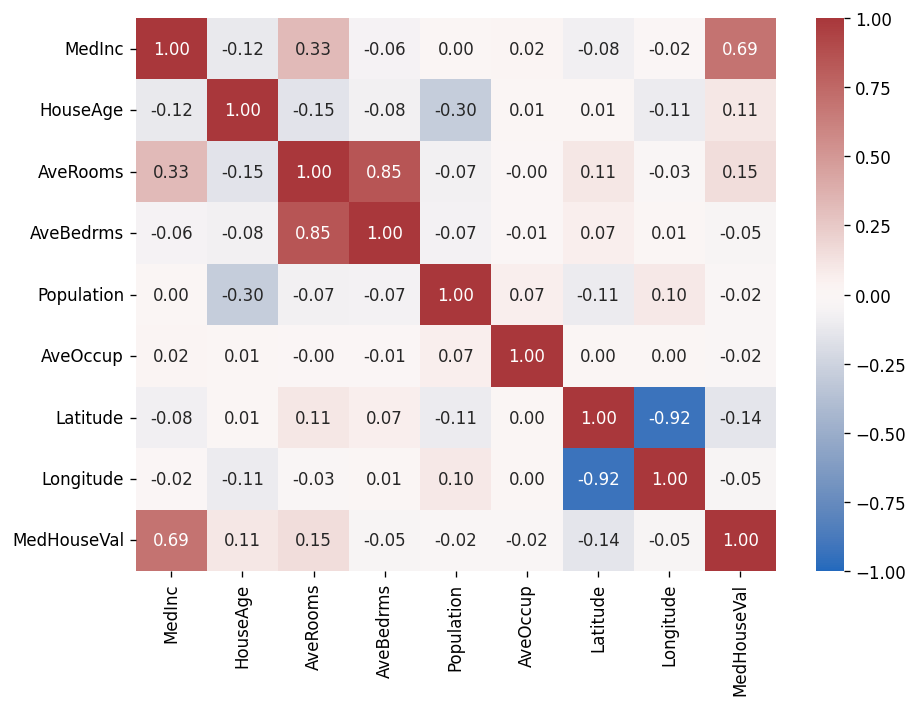

In [7]:
corr = analise.corr()
fig, ax = plt.subplots(figsize=(8,6), dpi=120)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag', center=0, vmin=-1, vmax=1, ax=ax)
fig.tight_layout()
plt.show()

In [8]:
df = analise[['MedInc', 'MedHouseVal']].copy()

C:\Users\RAFAEL\AppData\Local\Temp\ipykernel_21144\964070009.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


<Axes: xlabel='MedHouseVal', ylabel='MedInc'>

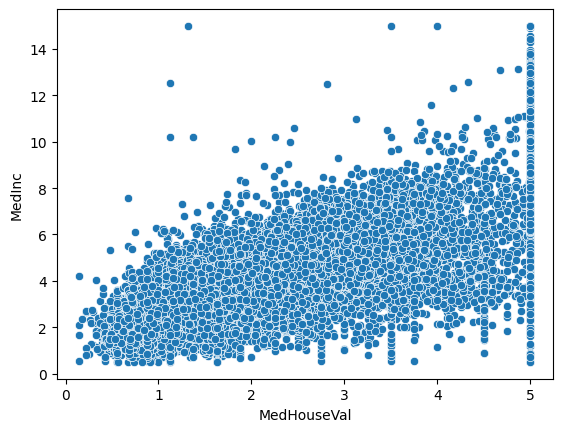

In [11]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=df, 
    y="MedInc", 
    x="MedHouseVal",
    palette="colorblind",
    ax=ax
)

In [13]:
# Como não tem diferença vou manter o original
X = df['MedInc'].to_numpy()
Y = df['MedHouseVal'].to_numpy()

train_pct_index = int(0.8 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = Y[:train_pct_index], Y[train_pct_index:]

print(len(X_train)) # 80% -> não sei como shufflar sem uma biblioteca e não queria usar uma também
print(len(X_test))

16512
4128


In [30]:
class LMSTrainer:

    def __init__(self, a, iter, limiar):

        self.w0, self.w1 = 0,0 # pesos
        self.a = a # taxa de aprendizagem
        self.iter = iter # quantidade de iterações = epochs
        self.limiar = limiar

    def train(self, x, y):
        

        for i in range(self.iter) :

            # predição do modelo
            y_pred = self.w0 + self.w1 * x

            print("Erro médio -> ", (1/len(x)) * np.sum((y_pred - y)**2))

            #                   a        1/m       E(h0(x) - y)                                       
            w0_t = self.w0 - self.a * (1/len(x)) * np.sum((y_pred - y))
            w1_t = self.w1 - self.a * (1/len(x)) * np.sum((y_pred - y) * x)

            self.w0 = w0_t
            self.w1 = w1_t

        return self.w0, self.w1

In [35]:
modelo_regressao_linear = LMSTrainer(
    a=0.001,
    iter=100000,
    limiar=0.001
)
vetores_peso = modelo_regressao_linear.train(X_train, y_train)
print(vetores_peso)

Erro médio ->  5.371790522291224
Erro médio ->  5.19933031410277
Erro médio ->  5.033279590157941
Erro médio ->  4.873400128715191
Erro médio ->  4.719462562041767
Erro médio ->  4.571246047335965
Erro médio ->  4.428537949880253
Erro médio ->  4.291133537970671
Erro médio ->  4.158835689184819
Erro médio ->  4.031454607567003
Erro médio ->  3.9088075513247897
Erro médio ->  3.790718570646293
Erro médio ->  3.6770182552620168
Erro médio ->  3.567543491389101
Erro médio ->  3.4621372277092357
Erro médio ->  3.360648250044499
Erro médio ->  3.2629309644078344
Erro médio ->  3.1688451881169146
Erro médio ->  3.0782559486716923
Erro médio ->  2.9910332901070884
Erro médio ->  2.9070520865429863
Erro médio ->  2.8261918626640328
Erro médio ->  2.7483366208716755
Erro médio ->  2.673374674860467
Erro médio ->  2.6011984893798425
Erro médio ->  2.531704525951493
Erro médio ->  2.4647930943209726
Erro médio ->  2.400368209430413
Erro médio ->  2.3383374537071564
Erro médio ->  2.27861184447070

In [36]:
class LMSPredictor:
    def __init__(self, w0, w1):
        self.w0 = w0
        self.w1 = w1

    def predict(self, x):
        a = self.w0 + self.w1*x
        print("w0 = ", self.w0)
        print("w1 = ", self.w1)
        print("x = ", x)
        return a

In [37]:
preditor = LMSPredictor(vetores_peso[0], vetores_peso[1])

In [38]:
print(f"Entrada: " ,X_test[0], ", saída -> ", y_test[0])
a = X_test[0]
print(f"Entrada: " ,X_test[0], ", saída -> ", preditor.predict(a))

Entrada:  2.6368 , saída ->  1.656
w0 =  0.47027446812018714
w1 =  0.40795045412690123
x =  2.6368
Entrada:  2.6368 , saída ->  1.5459582255620004
